<a href="https://colab.research.google.com/github/FriedIce-623/Calcium-Carbide-Detection/blob/main/calciumCarbideDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
!pip install -q gdown --upgrade
print("Downloading dataset")
!git clone --depth=1 --quiet https://github.com/luischuquim/BananaRipeness.git /content/BananaRipeness
print("done")

done


In [14]:
!find "/content/BananaRipeness" -maxdepth 4 -type d

/content/BananaRipeness
/content/BananaRipeness/.git
/content/BananaRipeness/.git/logs
/content/BananaRipeness/.git/logs/refs
/content/BananaRipeness/.git/logs/refs/heads
/content/BananaRipeness/.git/logs/refs/remotes
/content/BananaRipeness/.git/info
/content/BananaRipeness/.git/refs
/content/BananaRipeness/.git/refs/heads
/content/BananaRipeness/.git/refs/remotes
/content/BananaRipeness/.git/refs/remotes/origin
/content/BananaRipeness/.git/refs/tags
/content/BananaRipeness/.git/hooks
/content/BananaRipeness/.git/branches
/content/BananaRipeness/.git/objects
/content/BananaRipeness/.git/objects/info
/content/BananaRipeness/.git/objects/pack
/content/BananaRipeness/Banana Images
/content/BananaRipeness/Banana Images/Real Dataset
/content/BananaRipeness/Banana Images/Real Dataset/test
/content/BananaRipeness/Banana Images/Real Dataset/test/Class A
/content/BananaRipeness/Banana Images/Real Dataset/test/Class C
/content/BananaRipeness/Banana Images/Real Dataset/test/Class B
/content/Bana

In [16]:
for root, dirs, files_list in os.walk('/content/BananaRipeness'):
    level = root.replace('/content/BananaRipeness', '').count(os.sep)
    if level > 2: continue
    indent = '  ' * level
    folder_name = os.path.basename(root)
    imgs = [f for f in files_list if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if imgs:
        print(f"{indent}{folder_name}/  → {len(imgs)} images")
    elif level < 2:
        print(f"{indent}{folder_name}/")

BananaRipeness/  → 10 images
  .git/
  Banana Images/


In [15]:
TRAIN_DIR = "/content/BananaRipeness/Banana Images/Real Dataset/train"
VAL_DIR   = "/content/BananaRipeness/Banana Images/Real Dataset/validation"
TEST_DIR  = "/content/BananaRipeness/Banana Images/Real Dataset/test"

print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)
print("Classes:")
total = 0
for cls, count in class_info:
    print(f"  {cls}: {count} images")
    total += count
print(f"  TOTAL: {total} images")

Train: /content/BananaRipeness/Banana Images/Real Dataset/train
Validation: /content/BananaRipeness/Banana Images/Real Dataset/validation
Test: /content/BananaRipeness/Banana Images/Real Dataset/test
Classes:
  Class A: 286 images
  Class B: 163 images
  Class C: 112 images
  Class D: 138 images
  TOTAL: 699 images


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50, DenseNet201
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.preprocessing import label_binarize

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" GPU detected: {gpus[0].name}")
else:
    print(" No GPU! Go to Runtime → Change runtime type → T4 GPU for faster training")

# ── HYPERPARAMETERS (matching paper exactly) ───────────────────────────────
IMG_SIZE   = (224, 224)   # Paper uses 224x224
BATCH_SIZE = 32           # Standard batch size
EPOCHS     = 50           # EarlyStopping will stop early if converged
LR         = 1e-4         # Learning rate for Adam
DROPOUT    = 0.2          # Paper states 20% dropout
SEED       = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)
print("\n Config ready")

TensorFlow: 2.20.0
 GPU detected: /physical_device:GPU:0

 Config ready


In [28]:
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels 0-255 → 0.0-1.
                                  # Random rotation up to 30°
    rotation_range=20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],            # Random horizontal flip
    fill_mode='nearest'       # Fill empty pixels after transformatio
)

# ── VALIDATION GENERATOR: only rescale, NO augmentation ───────────────────
val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False           # MUST be False for correct evaluation

)
test_gen = val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


NUM_CLASSES  = len(train_gen.class_indices)
CLASS_NAMES  = list(train_gen.class_indices.keys())
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

print(f"\nClasses         : {CLASS_NAMES}")
print(f"Num classes     : {NUM_CLASSES}")
print(f"Training images : {train_gen.samples}")
print(f"Val images      : {val_gen.samples}")
print(f"Test images     : {test_gen.samples}")
print(f"Steps per epoch : {train_gen.samples // BATCH_SIZE}")

Found 2096 images belonging to 4 classes.
Found 700 images belonging to 4 classes.
Found 699 images belonging to 4 classes.

Classes         : ['Class A', 'Class B', 'Class C', 'Class D']
Num classes     : 4
Training images : 2096
Val images      : 700
Test images     : 699
Steps per epoch : 65


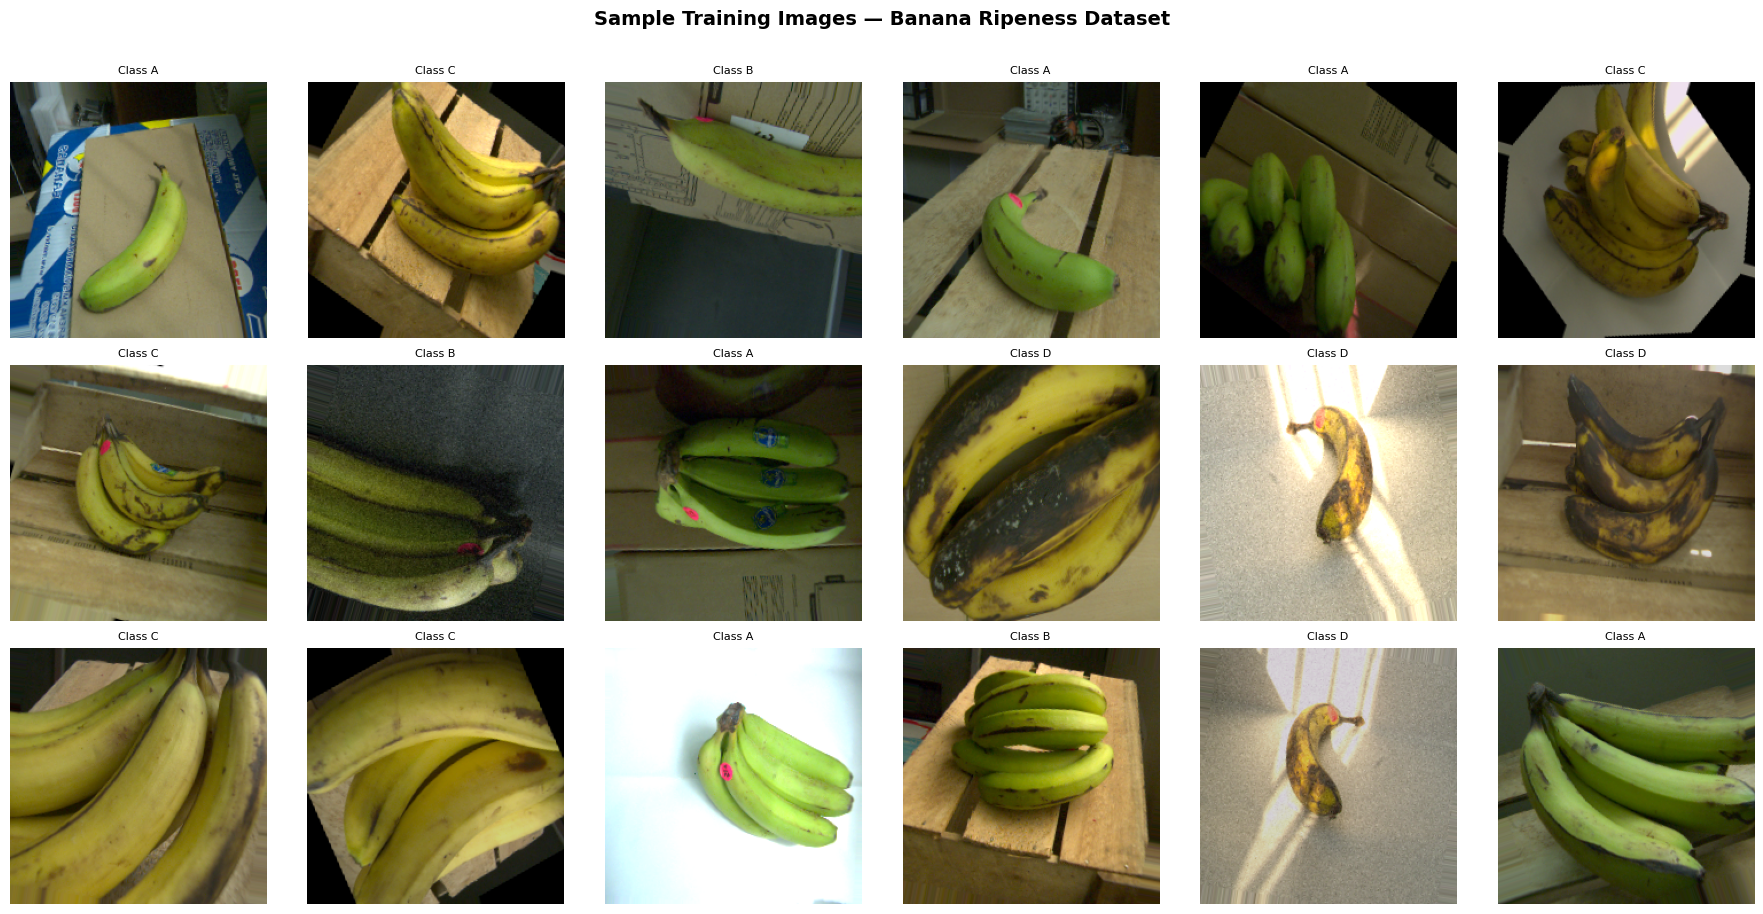

Saved → /content/sample_images.png


In [29]:
images, labels = next(train_gen)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Sample Training Images — Banana Ripeness Dataset',
             fontsize=14, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        ax.set_title(idx_to_class[np.argmax(labels[i])], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/sample_images.png")

In [30]:
def build_model(base_fn, num_classes, dropout=0.2, lr=1e-4):
    """
    Builds transfer learning model with the exact head from the paper.
    base_fn   : keras application e.g. ResNet50, DenseNet201
    """
    # ── PIECE 1: Pretrained base — all layers frozen ───────────────────────
    base = base_fn(
        weights='imagenet',      # Load ImageNet weights
        include_top=False,       # Remove original classifier
        input_shape=(224, 224, 3)
    )
    base.trainable = False       # Freeze — do not update during training

    # ── PIECE 2: Custom head — trained from scratch ────────────────────────
    x = base.output
    x = layers.GlobalAveragePooling2D()(x)   # e.g. (7,7,2048) → (2048,)

    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=outputs)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# ── BUILD RESNET-50 ────────────────────────────────────────────────────────
print("Building ResNet-50...")
resnet_model = build_model(ResNet50, NUM_CLASSES, DROPOUT, LR)
trainable_rn = sum(tf.size(w).numpy() for w in resnet_model.trainable_weights)
print(f"  Total params     : {resnet_model.count_params():,}")
print(f"  Trainable params : {trainable_rn:,}  (only the custom head)")

# ── BUILD DENSENET-201 ─────────────────────────────────────────────────────
print("\nBuilding DenseNet-201...")
densenet_model = build_model(DenseNet201, NUM_CLASSES, DROPOUT, LR)
trainable_dn = sum(tf.size(w).numpy() for w in densenet_model.trainable_weights)
print(f"  Total params     : {densenet_model.count_params():,}")
print(f"  Trainable params : {trainable_dn:,}  (only the custom head)")

print("\n Both models ready")

Building ResNet-50...
  Total params     : 24,772,228
  Trainable params : 1,182,980  (only the custom head)

Building DenseNet-201...
  Total params     : 19,440,964
  Trainable params : 1,117,444  (only the custom head)

 Both models ready


In [31]:
def get_callbacks(name):
    """Three callbacks: stop early, reduce LR, save best model."""
    return [
        # Stop training if val_loss hasn't improved in 10 epochs
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,  # Revert to best weights on stop
            verbose=1
        ),
        # Halve the learning rate after 5 epochs of no improvement
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        # Always save the best model to disk
        ModelCheckpoint(
            filepath=f'/content/{name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]

print(" Callbacks ready")

 Callbacks ready


In [32]:
print("="*55)
print("  TRAINING ResNet-50")
print("="*55)

resnet_history = resnet_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('resnet50'),
    verbose=1
)

best_rn = max(resnet_history.history['val_accuracy'])
print(f"\n ResNet-50 best val accuracy: {best_rn*100:.2f}%")

  TRAINING ResNet-50
Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 60s 726ms/step - accuracy: 0.4070 - loss: 1.5472 - val_accuracy: 0.2400 - val_loss: 1.4885 - learning_rate: 1.0000e-04
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 526ms/step - accuracy: 0.4695 - loss: 1.3677 - val_accuracy: 0.2657 - val_loss: 1.5209 - learning_rate: 1.0000e-04
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 510ms/step - accuracy: 0.5191 - loss: 1.2247 - val_accuracy: 0.2386 - val_loss: 1.7837 - learning_rate: 1.0000e-04
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 529ms/step - accuracy: 0.5210 - loss: 1.1809 - val_accuracy: 0.2600 - val_loss: 1.9859 - learning_rate: 1.0000e-04
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 35s 526ms/step - accuracy: 0.5477 - loss: 1.1317 - val_accuracy: 0.2657 - val_loss: 1.5544 - learning_rate: 1.0000e-04
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.5698 - loss: 1.0696
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
66/66 ━━━━━━━━━━━━━━━━━━━━ 34s 5

In [33]:
print("="*55)
print("  TRAINING DenseNet-201")
print("="*55)

densenet_history = densenet_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks('densenet201'),
    verbose=1
)

best_dn = max(densenet_history.history['val_accuracy'])
print(f"\n DenseNet-201 best val accuracy: {best_dn*100:.2f}%")

  TRAINING DenseNet-201
Epoch 1/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.6093 - loss: 1.0372 - val_accuracy: 0.6200 - val_loss: 0.9237 - learning_rate: 1.0000e-04
Epoch 2/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 602ms/step - accuracy: 0.7791 - loss: 0.5704 - val_accuracy: 0.8100 - val_loss: 0.5740 - learning_rate: 1.0000e-04
Epoch 3/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 603ms/step - accuracy: 0.8344 - loss: 0.4554 - val_accuracy: 0.8586 - val_loss: 0.4097 - learning_rate: 1.0000e-04
Epoch 4/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 608ms/step - accuracy: 0.8564 - loss: 0.3801 - val_accuracy: 0.8829 - val_loss: 0.3252 - learning_rate: 1.0000e-04
Epoch 5/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 40s 605ms/step - accuracy: 0.8669 - loss: 0.3576 - val_accuracy: 0.8843 - val_loss: 0.3106 - learning_rate: 1.0000e-04
Epoch 6/50
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 556ms/step - accuracy: 0.8798 - loss: 0.3213 - val_accuracy: 0.8829 - val_loss: 0.2861 - learning_rate: 1.0000e-04
Epoch 7/50
66/66 ━━━━━━━━━━━━━━━━━━━

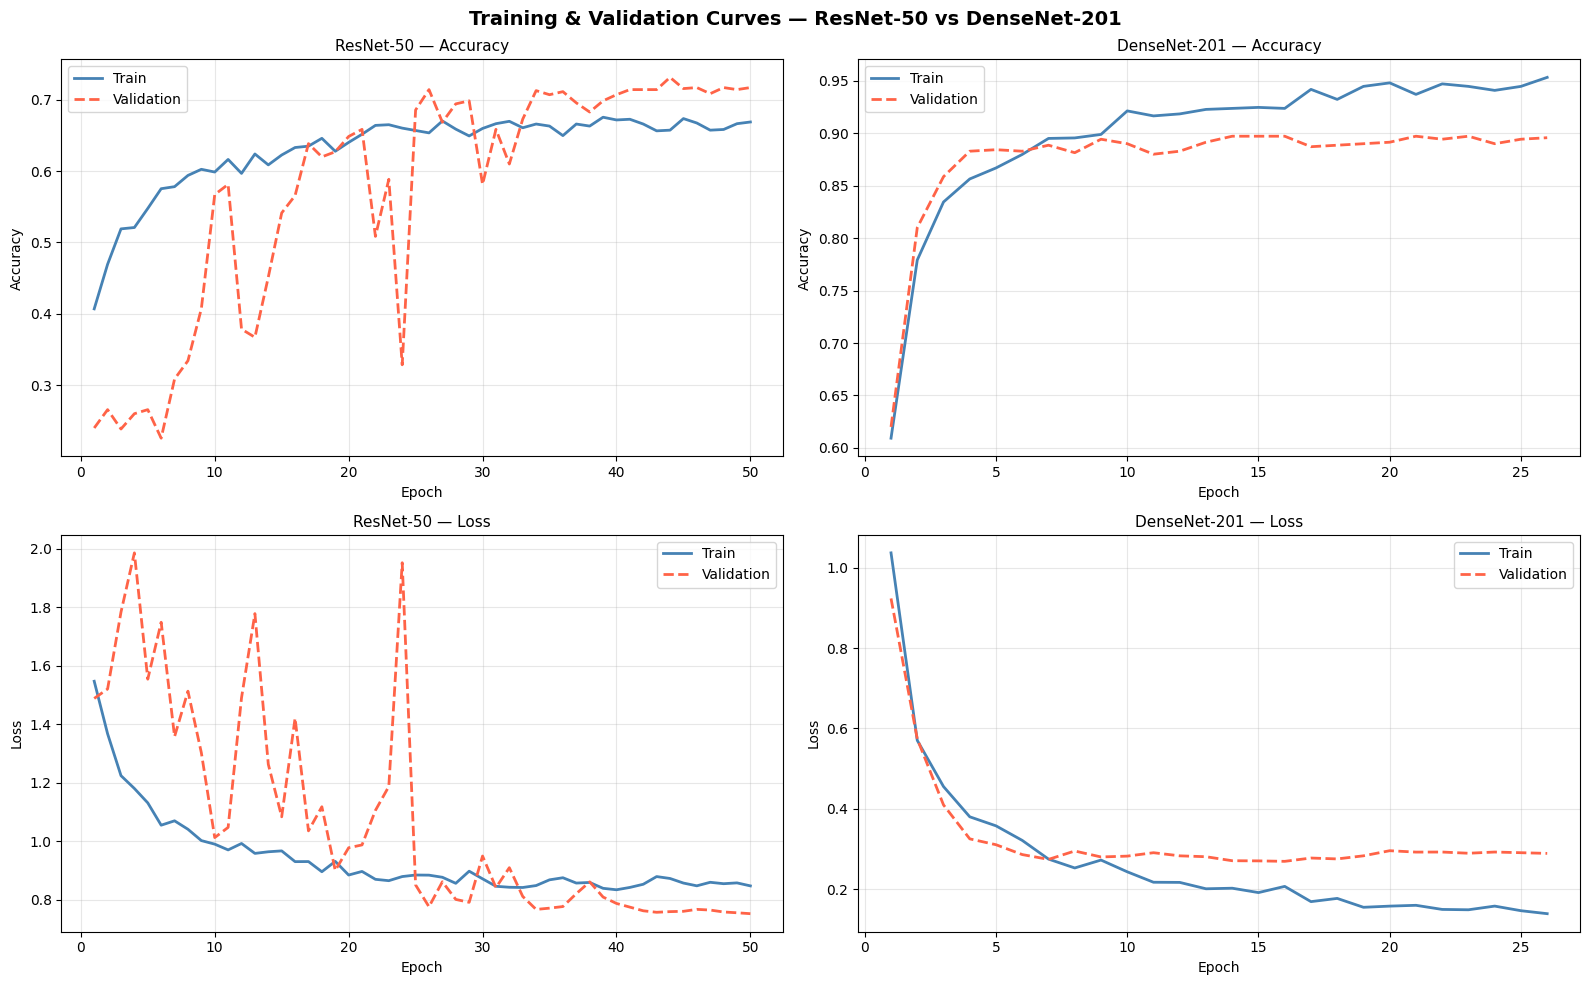

Saved → /content/training_curves.png


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Training & Validation Curves — ResNet-50 vs DenseNet-201',
             fontsize=14, fontweight='bold')

configs = [
    (axes[0,0], resnet_history,   'accuracy', 'ResNet-50 — Accuracy'),
    (axes[0,1], densenet_history, 'accuracy', 'DenseNet-201 — Accuracy'),
    (axes[1,0], resnet_history,   'loss',     'ResNet-50 — Loss'),
    (axes[1,1], densenet_history, 'loss',     'DenseNet-201 — Loss'),
]

for ax, hist, metric, title in configs:
    ep = range(1, len(hist.history[metric]) + 1)
    ax.plot(ep, hist.history[metric],
            label='Train', lw=2, color='steelblue')
    ax.plot(ep, hist.history[f'val_{metric}'],
            label='Validation', lw=2, color='tomato', ls='--')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/training_curves.png")

In [35]:
resnet_model.evaluate(test_gen)
densenet_model.evaluate(test_gen)

22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 368ms/step - accuracy: 0.7396 - loss: 0.6950
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9127 - loss: 0.2707


[0.27067360281944275, 0.9127324819564819]

In [36]:
# IMPORTANT: Always reset generator before predicting
val_gen.reset()
rn_probs = resnet_model.predict(val_gen, verbose=1)
rn_preds = np.argmax(rn_probs, axis=1)

val_gen.reset()
dn_probs = densenet_model.predict(val_gen, verbose=1)
dn_preds = np.argmax(dn_probs, axis=1)

# True labels (val_gen.classes is only valid after shuffle=False)
true_labels = val_gen.classes

print("\n" + "="*52)
print("ResNet-50 — Classification Report")
print("="*52)
print(classification_report(true_labels, rn_preds, target_names=CLASS_NAMES))

print("\n" + "="*52)
print("DenseNet-201 — Classification Report")
print("="*52)
print(classification_report(true_labels, dn_preds, target_names=CLASS_NAMES))

22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 293ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step

ResNet-50 — Classification Report
              precision    recall  f1-score   support

     Class A       0.81      0.92      0.86       286
     Class B       0.59      0.45      0.51       163
     Class C       0.56      0.57      0.57       112
     Class D       0.74      0.73      0.74       139

    accuracy                           0.72       700
   macro avg       0.68      0.67      0.67       700
weighted avg       0.71      0.72      0.71       700


DenseNet-201 — Classification Report
              precision    recall  f1-score   support

     Class A       0.97      0.93      0.95       286
     Class B       0.79      0.85      0.82       163
     Class C       0.83      0.79      0.81       112
     Class D       0.94      0.97      0.96       139

    accuracy                           0.90       700
   macro avg       0.88      0.88      0.88       700
weighted avg       0.90      0.

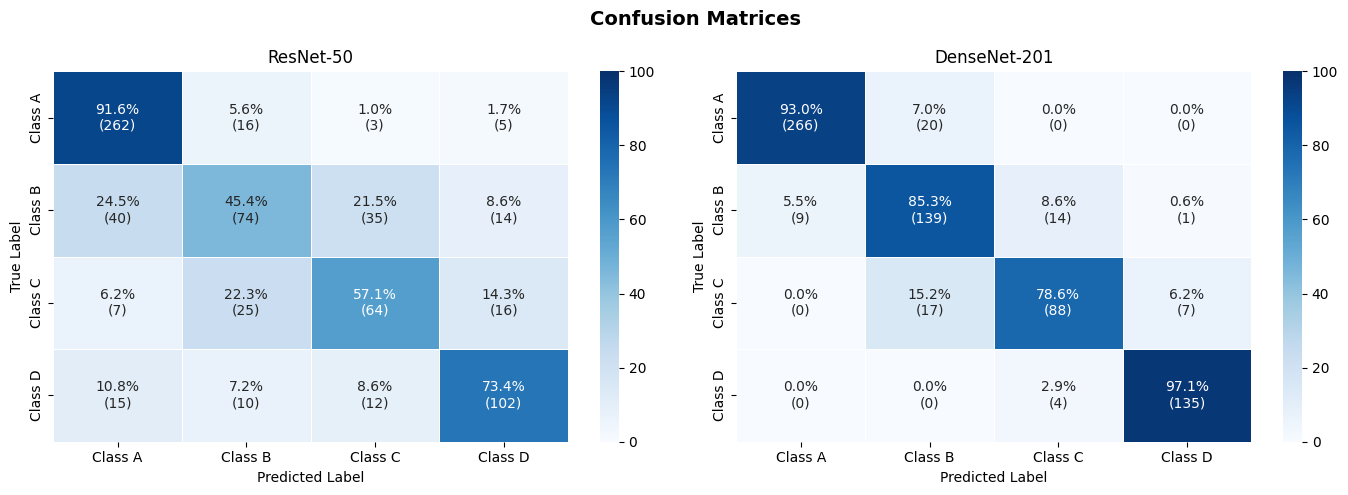

Saved → /content/confusion_matrices.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')

for ax, preds, title in [
    (axes[0], rn_preds, 'ResNet-50'),
    (axes[1], dn_preds, 'DenseNet-201')
]:
    cm      = confusion_matrix(true_labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100

    # Show both percentage and raw count in each cell
    annot = np.array([
        [f"{cm_norm[i,j]:.1f}%\n({cm[i,j]})" for j in range(NUM_CLASSES)]
        for i in range(NUM_CLASSES)
    ])

    sns.heatmap(
        cm_norm, annot=annot, fmt='',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cmap='Blues', ax=ax,
        linewidths=0.5, linecolor='white',
        vmin=0, vmax=100
    )
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/confusion_matrices.png")

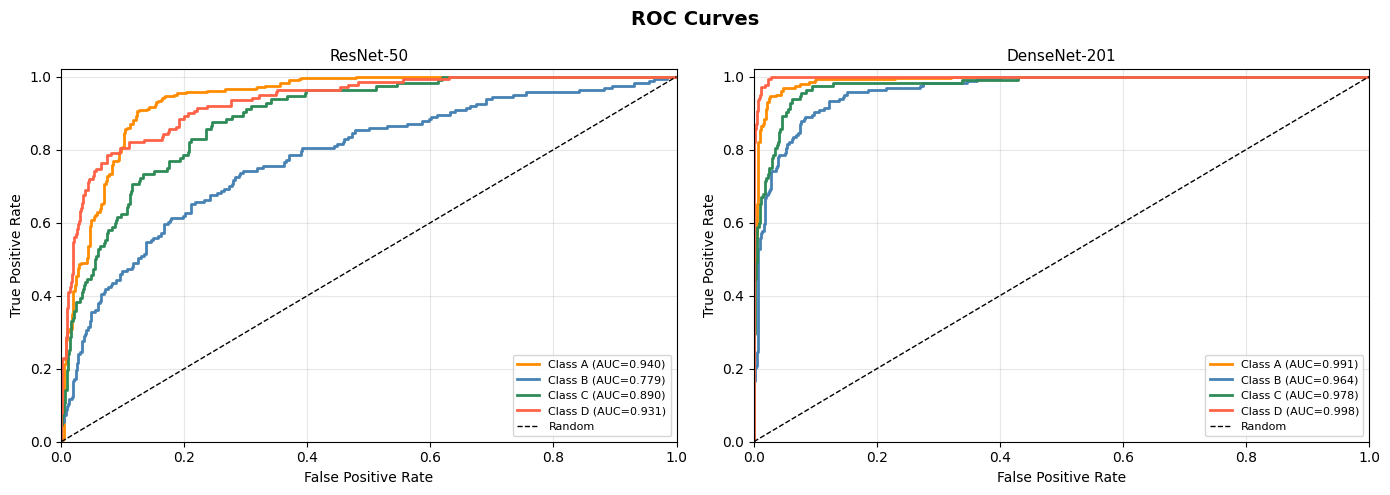

Saved → /content/roc_curves.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ROC Curves', fontsize=14, fontweight='bold')

colors = ['darkorange','steelblue','seagreen','tomato','purple','brown']

for ax, probs, title in [
    (axes[0], rn_probs, 'ResNet-50'),
    (axes[1], dn_probs, 'DenseNet-201')
]:
    if NUM_CLASSES == 2:
        # Binary classification — single ROC curve
        fpr, tpr, _ = roc_curve(true_labels, probs[:, 1])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, color='darkorange',
                label=f'AUC = {roc_auc:.4f}')
    else:
        # Multi-class — one ROC curve per class
        true_bin = label_binarize(true_labels, classes=list(range(NUM_CLASSES)))
        for i, cls in enumerate(CLASS_NAMES):
            fpr, tpr, _ = roc_curve(true_bin[:, i], probs[:, i])
            roc_auc     = auc(fpr, tpr)
            ax.plot(fpr, tpr, lw=2, color=colors[i % len(colors)],
                    label=f'{cls} (AUC={roc_auc:.3f})')

    ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=11)
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/roc_curves.png")

In [39]:
def compute_metrics(true, preds, probs):
    avg = 'binary' if NUM_CLASSES == 2 else 'weighted'

    if NUM_CLASSES == 2:
        fpr, tpr, _ = roc_curve(true, probs[:, 1])
    else:
        tb = label_binarize(true, classes=list(range(NUM_CLASSES)))
        fpr, tpr, _ = roc_curve(tb.ravel(), probs.ravel())

    return {
        'Accuracy'  : f"{accuracy_score(true, preds)*100:.2f}%",
        'Precision' : f"{precision_score(true, preds, average=avg, zero_division=0)*100:.2f}%",
        'Recall'    : f"{recall_score(true, preds, average=avg)*100:.2f}%",
        'F1-Score'  : f"{f1_score(true, preds, average=avg)*100:.2f}%",
        'AUC-ROC'   : f"{auc(fpr, tpr):.4f}"
    }

rn_m = compute_metrics(true_labels, rn_preds, rn_probs)
dn_m = compute_metrics(true_labels, dn_preds, dn_probs)

print("\n" + "="*62)
print("  TABLE 2 — Model Performance Comparison")
print("="*62)
print(f"{'Metric':<15} {'ResNet-50':>20} {'DenseNet-201':>20}")
print("-"*62)
for m in ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']:
    print(f"{m:<15} {rn_m[m]:>20} {dn_m[m]:>20}")
print("="*62)


  TABLE 2 — Model Performance Comparison
Metric                     ResNet-50         DenseNet-201
--------------------------------------------------------------
Accuracy                      71.71%               89.71%
Precision                     70.59%               89.94%
Recall                        71.71%               89.71%
F1-Score                      70.80%               89.77%
AUC-ROC                       0.9045               0.9864


In [40]:
# Save final models
resnet_model.save('/content/resnet50_final.keras')
densenet_model.save('/content/densenet201_final.keras')
print("Models saved.")

# Zip all output files together
!zip -q /content/results.zip \
    /content/sample_images.png \
    /content/training_curves.png \
    /content/confusion_matrices.png \
    /content/roc_curves.png \
    /content/resnet50_best.keras \
    /content/densenet201_best.keras

print("All results zipped → /content/results.zip")

# Download zip to your computer
from google.colab import files
files.download('/content/results.zip')
print("✅ Download started!")

Models saved.
All results zipped → /content/results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started!


In [48]:
FINE_TUNE = True   # ← Set to True to enable fine-tuning

if FINE_TUNE:
    print("Fine-tuning ResNet-50: unfreezing last 20 layers...")

    # Unfreeze the last 20 layers of the base
    for layer in resnet_model.layers[:175]:
      layer.trainable = False
    for layer in resnet_model.layers[155:175]:
      layer.trainable = True

    # Recompile at a very low learning rate
    resnet_model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

    train_gen.reset()
    val_gen.reset()

    ft_history = resnet_model.fit(
        train_gen,
        epochs=20,
        validation_data=val_gen,
        callbacks=get_callbacks('resnet50_finetuned'),
        verbose=1
    )
    print(" Fine-tuning complete.")
else:
    print("Fine-tuning skipped. Set FINE_TUNE = True above to enable.")

Fine-tuning ResNet-50: unfreezing last 20 layers...
Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 73s 797ms/step - accuracy: 0.4704 - loss: 1.4573 - val_accuracy: 0.1843 - val_loss: 6.6892 - learning_rate: 1.0000e-05
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 550ms/step - accuracy: 0.5668 - loss: 1.1406 - val_accuracy: 0.1600 - val_loss: 11.2075 - learning_rate: 1.0000e-05
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 553ms/step - accuracy: 0.5940 - loss: 1.0526 - val_accuracy: 0.1600 - val_loss: 11.2603 - learning_rate: 1.0000e-05
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 556ms/step - accuracy: 0.6073 - loss: 1.0281 - val_accuracy: 0.1629 - val_loss: 4.7115 - learning_rate: 1.0000e-05
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 556ms/step - accuracy: 0.6427 - loss: 0.9536 - val_accuracy: 0.5086 - val_loss: 1.4932 - learning_rate: 1.0000e-05
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 558ms/step - accuracy: 0.6379 - loss: 0.9322 - val_accuracy: 0.5443 - val_loss: 1.2293 - learning_rate: 1.0000e-05
Epoc

In [50]:
import os

os.makedirs("saved_models", exist_ok=True)

In [51]:
resnet_model.save("saved_models/resnet50_finetuned.keras")
densenet_model.save("saved_models/densenet201_finetuned.keras")